# I. Data preparation

## Load CIFAR10 dataset

In [45]:
from torchvision import datasets, transforms
import torch

torch.manual_seed(42)

data_path = './../data'

# Define BATCH SIZE = 32
BATCH_SIZE = 256

# Define the data transformation
transform_train_1 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(32),
    transforms.CenterCrop(32),
])

transform_train_2 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.RandomHorizontalFlip(1)
])

transform_val = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor()
])


In [46]:
torch.manual_seed(42)
# Load the 2 datasets with different pre-processing methods
train_dataset_1 = datasets.CIFAR10(root=data_path, transform=transform_train_1, train=True, download=True)
train_dataset_2 = datasets.CIFAR10(root=data_path, transform=transform_train_2, train=True, download=True)
test_dataset = datasets.CIFAR10(root=data_path, transform=transform_val, train=False, download=True)

# # Concat train datasets
# train_dataset = torch.utils.data.ConcatDataset([train_dataset_1, train_dataset_2])

# # Train test split
# total_size = len(test_dataset)
# train_size = int(0.8 * total_size)
# test_size = total_size - train_size

# print(f"Total size of the dataset: {total_size}")
# print(f"Train size of the dataset: {train_size}")
# print(f"Test size of the dataset: {test_size}")

# generator = torch.Generator().manual_seed(42)
# train_indices, test_indices = torch.utils.data.random_split(
#     range(total_size), 
#     lengths=[train_size, test_size], 
#     generator=generator
# )

# # Create train, test splits from subset of loaded dataset
# train_dataset_split_1 = torch.utils.data.Subset(train_dataset_1, train_indices)
# train_dataset_split_2 = torch.utils.data.Subset(train_dataset_2, train_indices)
# test_dataset_split = torch.utils.data.Subset(test_dataset, test_indices)

# Concat 2 splitted train dataset
train_dataset_full = torch.utils.data.ConcatDataset([train_dataset_1, train_dataset_2])

# Load train and test data using DataLoader
train_dataloader = torch.utils.data.DataLoader(dataset=train_dataset_full, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True)


c:\Users\z5719157\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [47]:
test_dataset.data[0].shape


(32, 32, 3)

In [48]:
images, labels = next(iter(train_dataloader))
print(images.shape)

torch.Size([256, 3, 32, 32])


In [49]:

imagenet_labels_map = test_dataset.classes
print(f"Number of classes: {len(imagenet_labels_map)}")

Number of classes: 10


In [50]:
import matplotlib.pyplot as plt
torch.manual_seed(42)

def plot_samples(dataset, nrows=3, ncols=3, figname="Train samples"):
    plt.figure(figsize=(3*nrows, 3*ncols))
    # Plot 
    for i in range(1,nrows*ncols+1):
        plt.subplot(nrows, ncols, i)
        random_idx = torch.randint(0, len(dataset), size=[1]).item()
        img = dataset[random_idx][0]
        img_whc = img.permute(1, 2, 0)
        label_num = dataset[random_idx][1]
        plt.imshow(img_whc)
        plt.title(imagenet_labels_map[label_num], fontsize=10)
        
    

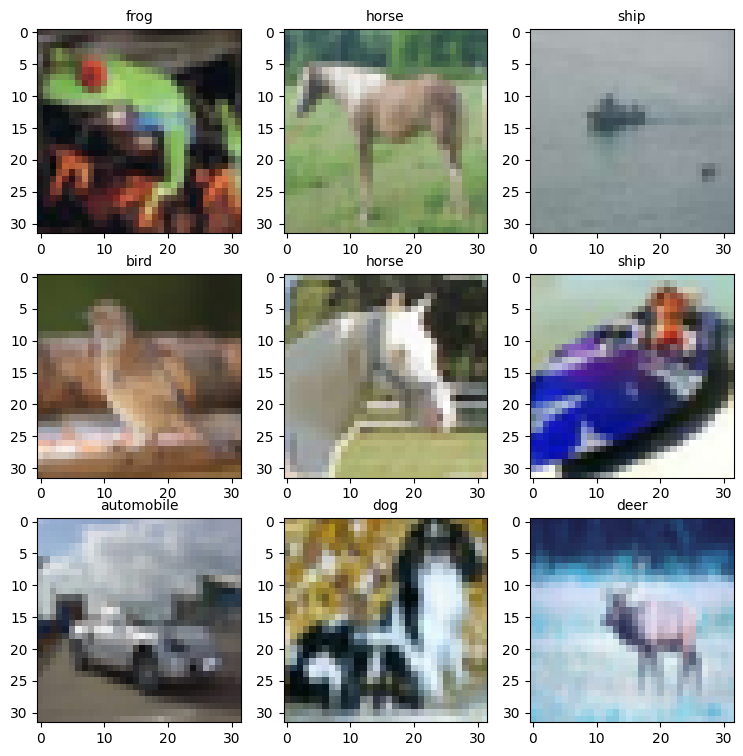

In [51]:
# Plot samples from train dataset
plot_samples(train_dataset_full, figname="Train samples visualization")

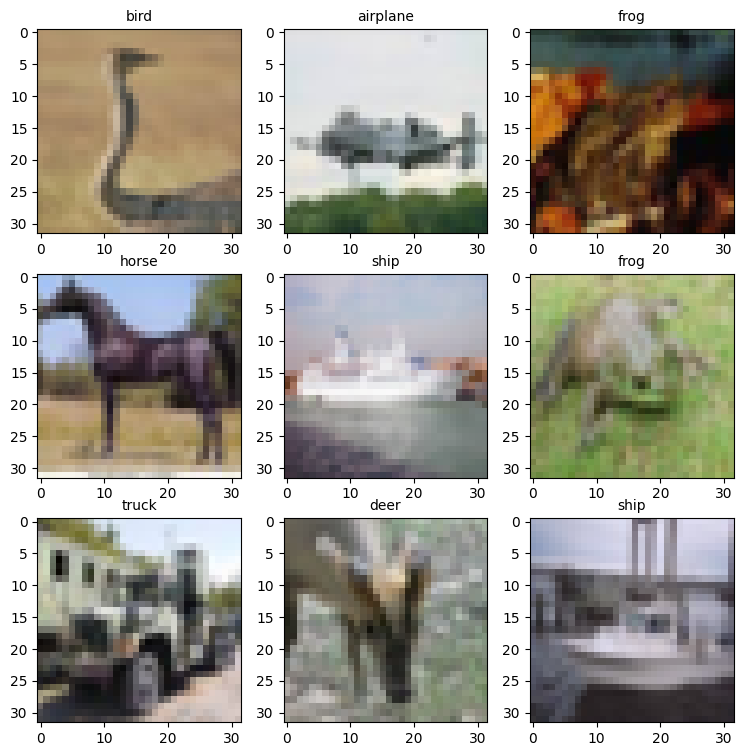

In [52]:
# Plot samples for test dataset
plot_samples(test_dataset, figname="Test samples visualization")

# Build ResNet model using for CIFAR-10 


In [53]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device


2.12.0+cu126


'cuda'

## Custom Normalization

In [54]:
import torch
from torch import nn
import math

**ResNet block**
$$\bold{y} = F(\bold{x}, \{W_i\} + \bold{x} = W_2\sigma(W_1\bold{x})) + \bold{x}$$

In [66]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, down_sampling=False):
        super().__init__()
        
        # Determine stride for the first convolution
        stride = 2 if down_sampling else 1
        
        # First layer (downsamples if stride=2)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second layer (always stride=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        
        # Projection shortcut
        self.shortcut = nn.Sequential()
        if down_sampling or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # Save input for the skip connection
        identity = self.shortcut(x)
        
        # Main path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Add skip connection BEFORE the final ReLU
        out += identity
        out = self.relu(out)
        
        return out
    
class ResNet(nn.Module):
    def __init__(self, conv1_channels, conv2_channels, conv3_channels, num_classes=10, depth=2):
        super().__init__()
        self.conv1_channels = conv1_channels
        self.conv2_channels = conv2_channels
        self.conv3_channels = conv3_channels
        self.depth = depth
        self.num_classes = num_classes
        self.resnet_layer = nn.Sequential(
            # Conv 0
            nn.Conv2d(in_channels=3, out_channels=self.conv1_channels, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(self.conv1_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
            
            # Conv 2 x 2
        self.conv1_list = [ResNetBlock(in_channels=self.conv1_channels, out_channels=self.conv1_channels, down_sampling=False) for i in range(2*depth)]
        self.conv1_stack = nn.ModuleList(self.conv1_list)
            # Conv 3 x 2
        self.conv2_list = [ResNetBlock(in_channels=self.conv1_channels, out_channels=self.conv2_channels, down_sampling=True)]
        for i in range(2*depth - 1):
            self.conv2_list.append(ResNetBlock(in_channels=self.conv2_channels, out_channels=self.conv2_channels, down_sampling=False))
        self.conv2_stack = nn.ModuleList(self.conv2_list)
            # Conv 4 x 2
        self.conv3_list = [ResNetBlock(in_channels=self.conv2_channels, out_channels=self.conv3_channels, down_sampling=True)]
        for i in range(2*depth - 1):
            self.conv3_list.append(ResNetBlock(in_channels=self.conv3_channels, out_channels=self.conv3_channels, down_sampling=False))
        self.conv3_stack = nn.ModuleList(self.conv3_list)


        self.dense_layer = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_features=self.conv3_channels, out_features=self.num_classes),
            nn.BatchNorm1d(self.num_classes),
        )
    
    def forward(self, X):
        out = self.resnet_layer(X)
        # Conv 1: 2n stacked layer, no down_sampling
        for i in range(2 * self.depth):
            out = self.conv1_stack[i](out)
        
        # Conv 2: 1 downsample convolution layer and 2n-1 consitent dimensions convolution layer
        for i in range(2 * self.depth):
            out = self.conv2_stack[i](out)

        # Conv 3: 1 downsample convolution layer and 2n-1 consitent dimensions convolution layer
        for i in range(2 * self.depth):
            out = self.conv3_stack[i](out)

        out = self.dense_layer(out)
        
        return out
        

In [67]:
X = torch.rand([3, 3, 3, 3])
X.shape[0]

3

## ResNetV1

In [68]:
model = ResNet(16, 32, 64, num_classes=10, depth=10)
model

ResNet(
  (resnet_layer): Sequential(
    (0): Conv2d(3, 16, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv1_stack): ModuleList(
    (0-19): 20 x ResNetBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential()
    )
  )
  (conv2_stack): ModuleList(
    (0): ResNetBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
 

## Prepare Loss function and Optimizer


In [69]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [70]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device):
    model.train()
    model.to(device)
    train_loss = 0
    train_acc = 0
    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true = y, y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (batch % 50 == 0):
            print(f"Training batch {batch} / {len(dataloader)}")
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    print(f"Train loss: {train_loss} | Train acc: {train_acc}")
    return train_loss, train_acc
    
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device="cpu"):
    model.to(device)
    model.eval()
    test_loss = 0
    test_acc = 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device)
            y = y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y, test_pred.argmax(dim=1))
            if (batch % 200 == 0):
                print(f"Testing batch {batch} / {len(dataloader)}")
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
    print(f"Test loss: {test_loss} | Test acc: {test_acc}")
    return test_loss, test_acc



In [71]:
hist = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
hist.keys()
hist['train_loss'].append(0)

In [ ]:
# Training loop
epochs = 100
print(device)
hist = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
print("Log history: ", hist.keys())

for epoch in range(epochs): 
    print(f"========= Epoch [{epoch+1}/{epochs}] with lr = {optimizer.param_groups[0]['lr']} =========")
    train_loss, train_acc = train_step(
        model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device='cuda'
    )

    scheduler.step()

    test_loss, test_acc = test_step(
        model=model,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device='cuda'
    )

    hist["train_loss"].append(train_loss)
    hist["train_acc"].append(train_acc)
    hist["test_loss"].append(test_loss)
    hist["test_acc"].append(test_acc)

    

cuda
Log history:  dict_keys(['train_loss', 'test_loss', 'train_acc', 'test_acc'])
========= Epoch [1/100] with lr = 0.01 =========
Training batch 0 / 391
Training batch 50 / 391
Training batch 100 / 391
Training batch 150 / 391
Training batch 200 / 391
Training batch 250 / 391
Training batch 300 / 391
Training batch 350 / 391
Train loss: 1.7557744443264154 | Train acc: 35.84738650895141
Testing batch 0 / 40
Test loss: 1.5468058675527572 | Test acc: 44.3359375
========= Epoch [2/100] with lr = 0.01 =========
Training batch 0 / 391
Training batch 50 / 391
Training batch 100 / 391
Training batch 150 / 391
Training batch 200 / 391
Training batch 250 / 391
Training batch 300 / 391
Training batch 350 / 391
Train loss: 1.4417819504237845 | Train acc: 48.374560421994886
Testing batch 0 / 40
Test loss: 1.4284846484661102 | Test acc: 49.052734375
========= Epoch [3/100] with lr = 0.01 =========
Training batch 0 / 391
Training batch 50 / 391
Training batch 100 / 391
Training batch 150 / 391
Trai

<class 'list'>
<class 'list'>
[0.9755680515796323, 1.0470545125913016, 1.0533094790917408, 0.8960434854785099, 0.9681005824970293, 1.1058145097539396, 0.9378828187532062, 0.9745802185203456, 0.9523308224315885, 0.9664666290524639, 1.0041282395773297, 0.9533224286912363, 0.9570497991163519, 0.9647117143944849, 0.9684398792967012, 0.9520120379291003, 1.0875888165039351, 0.9731849409356902, 1.2308064563364922, 1.1792482152769836, 1.007167332157304, 1.1421875998943667, 1.0280824019750463, 1.0813644309587116, 1.0843181097054784, 1.037215475040146, 1.0838474269154705, 1.0313865248161027, 1.1315979919856107, 1.098451874678648, 1.287941025782235, 1.055347459225715, 1.185244901270806, 0.9657007501095156, 1.071503693544412, 0.9533962622473512, 1.0445919217942636, 1.0500501152835315, 1.0739209825479532, 1.013087674786773, 1.084452142443838, 1.099652202069005, 1.0938103712057765, 1.068925318838675, 1.0817825726315946, 1.082620079004312, 0.9764529428904569, 1.004867101771922, 1.0097294585614265, 1.

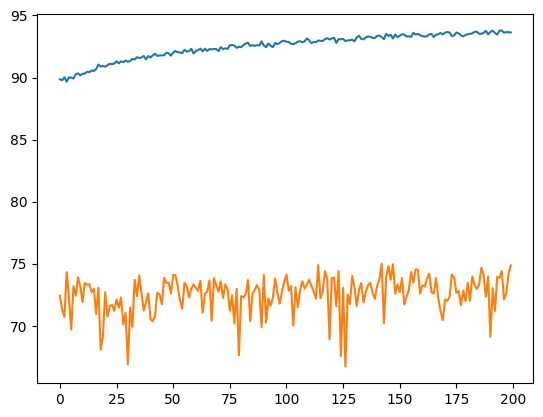

In [ ]:
import numpy as np

print(type(hist['train_acc']))
print(type(hist['test_loss']))

print(hist['test_loss'])
plt.plot(np.array(hist['train_acc']))
plt.plot(np.array(hist['test_acc']))

In [ ]:
test_dataset[0][0].shape

torch.Size([3, 224, 224])

In [42]:
torch.manual_seed(42)

def plot_predictions(dataset, nrows, ncols, model, figname):
    plt.figure(figsize=(4*nrows, 4*ncols))
    # Plot 
    with torch.inference_mode():
        for i in range(1,nrows*ncols+1):
            
            plt.subplot(nrows, ncols, i)
            
            model.to('cpu')
            model.eval()

            random_idx = torch.randint(0, len(dataset), size=[1]).item()
            img = dataset[random_idx][0]
            
            # Ground truth
            img_whc = img.permute(1, 2, 0)
            label_num = dataset[random_idx][1]
            
            # Predict value
            pred_label = torch.softmax(model(img.unsqueeze(dim=0)), dim=1).argmax(dim=1).item()
        
            plt.imshow(img_whc)
            if pred_label == label_num:
                plt.title(f"Ground truth: {imagenet_labels_map[label_num]} | Prediction: {imagenet_labels_map[pred_label]}", fontsize=10, c='g')
            else:
                plt.title(f"Ground truth: {imagenet_labels_map[label_num]} | Prediction: {imagenet_labels_map[pred_label]}", fontsize=10, c='r')
    

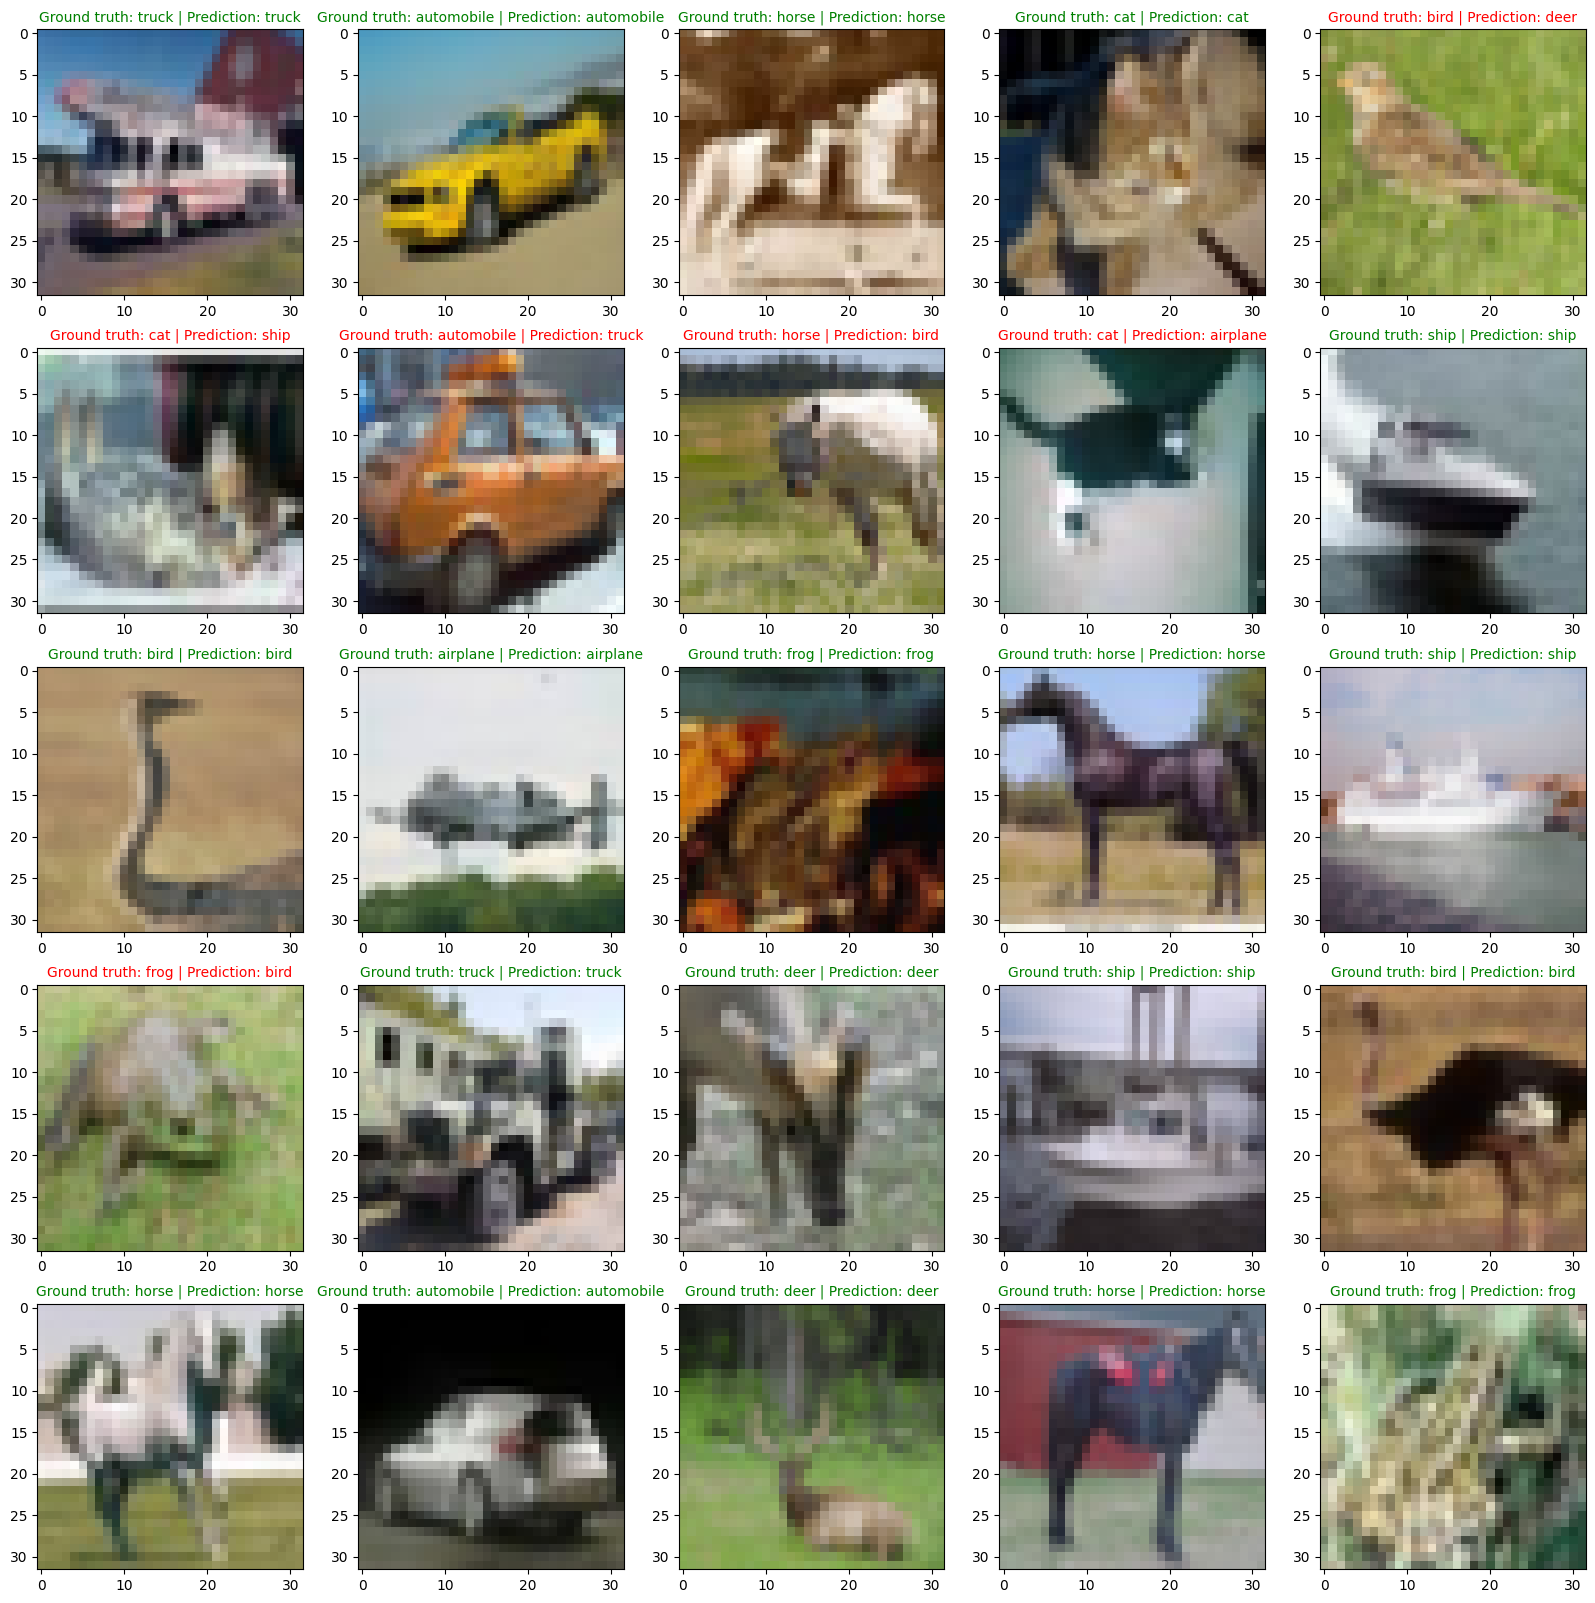

In [44]:
plot_predictions(test_dataset, 5, 5, model, "Predictions")

49
mountain


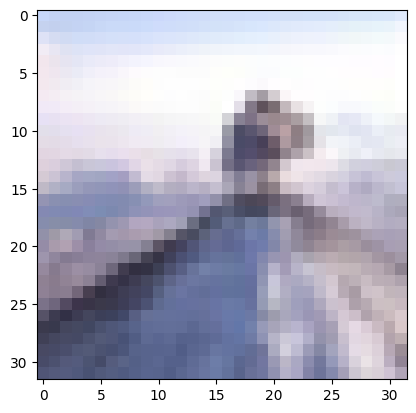

In [ ]:
# Visualize some result 

with torch.inference_mode():
    model.to('cpu')
    y_pred = torch.softmax(model(test_dataset[0][0].unsqueeze(dim=0)), dim=1).argmax(dim=1).item()
    print(y_pred)
    print(imagenet_labels_map[y_pred])
plt.imshow(test_dataset.data[0])